Actual Values: [1 0 1]
Predicted Values: [1 0 1]
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

Prediction: Not Purchased


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


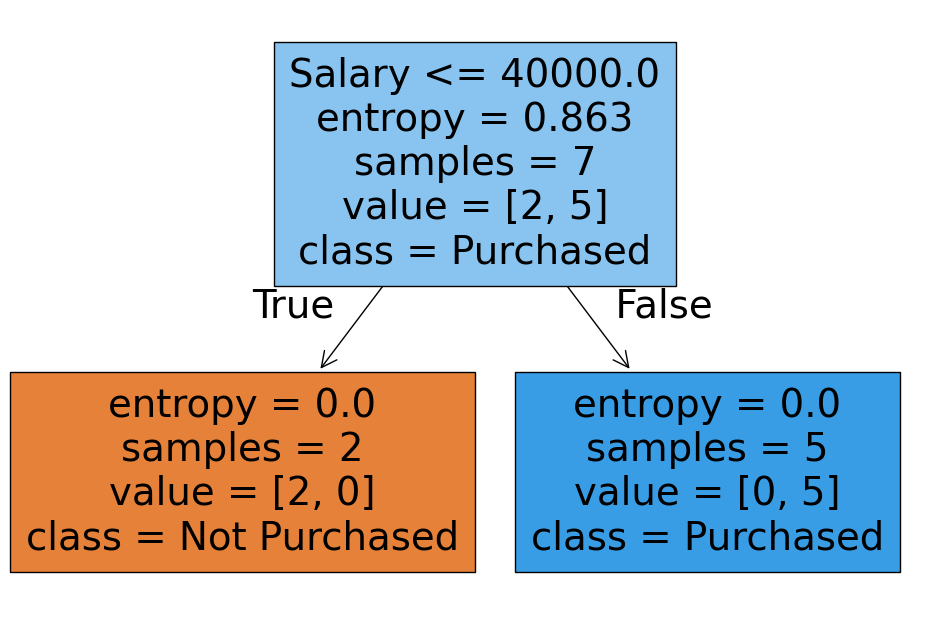

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

data = {
    "Age": [22, 25, 28, 32, 35, 40, 45, 50, 55, 60],
    "Salary": [25000, 30000, 35000, 45000, 50000, 60000, 70000, 80000, 90000, 100000],
    "Experience": [1, 2, 3, 5, 7, 10, 12, 15, 18, 20],
    "Purchased": [0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)

X = df[["Age", "Salary", "Experience"]]
y = df["Purchased"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Actual Values:", y_test.values)
print("Predicted Values:", y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

new_person = [[30, 40000, 4]]

prediction = model.predict(new_person)

if prediction[0] == 1:
    print("Prediction: Purchased")
else:
    print("Prediction: Not Purchased")

plt.figure(figsize=(12, 8))

plot_tree(
    model,
    feature_names=["Age", "Salary", "Experience"],
    class_names=["Not Purchased", "Purchased"],
    filled=True
)

plt.show()